# Sydney Airbnb Data Cleaning

**Goal:** prepare 20,573 raw listings for an analysis of active short-stay rentals.

Run one cell at a time and check the output before moving on. If something looks unexpected, investigate it first.

The notes explain what each step does and why it is useful for the analysis.


## Step 1: Load the raw file

We load the listing and host IDs as `int64` to preserve their full values. Large IDs can lose precision if they are stored as `float64`, which can cause problems when joining datasets.

Check the printed data types after loading the file. Both ID columns should be `int64`.


In [2]:
import pandas as pd
import numpy as np
import json

RAW_PATH = 'listings.csv'   # adjust to your path

df = pd.read_csv(RAW_PATH, low_memory=False, dtype={'id': 'int64', 'host_id': 'int64'})

print(f'Rows: {len(df):,}   Columns: {df.shape[1]}')
print(f'id dtype: {df["id"].dtype}   host_id dtype: {df["host_id"].dtype}')

Rows: 20,573   Columns: 90
id dtype: int64   host_id dtype: int64


## Step 2: Check for empty columns

Check how much data is missing in each column before deciding what to remove.

Columns that are completely empty can be dropped. For partially missing columns, consider whether the values can be filled using other information in the dataset.


In [3]:
null_pct = (df.isnull().mean() * 100).round(1).sort_values(ascending=False)
print('=== 100% empty (delete these) ===')
print(null_pct[null_pct == 100].to_string())
print()
print('=== Partially missing (repair these) ===')
print(null_pct[(null_pct > 0) & (null_pct < 100)].head(15).to_string())

=== 100% empty (delete these) ===
host_response_time              100.0
neighbourhood_group_cleansed    100.0
calendar_updated                100.0
neighbourhood                   100.0
host_verifications              100.0
host_total_listings_count       100.0
neighborhood_overview           100.0
instant_bookable                100.0
host_neighbourhood              100.0
host_thumbnail_url              100.0
host_acceptance_rate            100.0
host_response_rate              100.0
host_since                      100.0

=== Partially missing (repair these) ===
host_about                     41.6
host_location                  28.3
bathrooms                      27.8
beds                           24.5
review_scores_accuracy         16.2
review_scores_location         16.2
review_scores_rating           16.2
review_scores_value            16.2
first_review                   16.2
reviews_per_month              16.2
review_scores_communication    16.2
review_scores_cleanliness      16.

## Step 3: Check listing activity, stay length and host size

These counts give us an overview of the listings before cleaning.

- Dormant listings have no reviews in the last 12 months. We use this as an indicator of inactivity.
- Long-stay listings require at least 28 nights and fall outside the short-stay analysis.
- Commercial hosts have at least five listings. This helps us understand the mix of individual and larger operators.


In [4]:
dormant    = (df['number_of_reviews_ltm'] == 0).sum()
long_stay  = (df['minimum_nights'] >= 28).sum()
commercial = (df['calculated_host_listings_count'] >= 5).sum()

print(f'Dormant (no guest in 12mo) : {dormant:,}  ({dormant/len(df)*100:.1f}%)')
print(f'Long-stay (28+ nights)     : {long_stay:,}  ({long_stay/len(df)*100:.1f}%)')
print(f'Commercial host listings   : {commercial:,}  ({commercial/len(df)*100:.1f}%)')
print(f'Unique hosts               : {df["host_id"].nunique():,}')

Dormant (no guest in 12mo) : 5,884  (28.6%)
Long-stay (28+ nights)     : 2,987  (14.5%)
Commercial host listings   : 9,230  (44.9%)
Unique hosts               : 9,735


### Check the occupancy estimates

Compare the number of listings with zero estimated occupancy and zero reviews in the last 12 months.

Matching counts may suggest a relationship between the estimates and review activity, but they do not prove how the estimates were calculated. If revenue estimates are based on reviews, using review counts to predict those estimates could introduce target leakage.


In [5]:
a = (df['estimated_occupancy_l365d'] == 0).sum()
b = (df['number_of_reviews_ltm'] == 0).sum()
print(f'occupancy == 0      : {a:,}')
print(f'reviews_ltm == 0    : {b:,}')
print('IDENTICAL -> revenue estimates are derived from reviews' if a == b else 'Different')

occupancy == 0      : 5,884
reviews_ltm == 0    : 5,884
IDENTICAL -> revenue estimates are derived from reviews


## Step 4: Explore the data visually

Look at prices, review activity, minimum stays, host size and differences between suburbs. These plots help guide the cleaning decisions below.


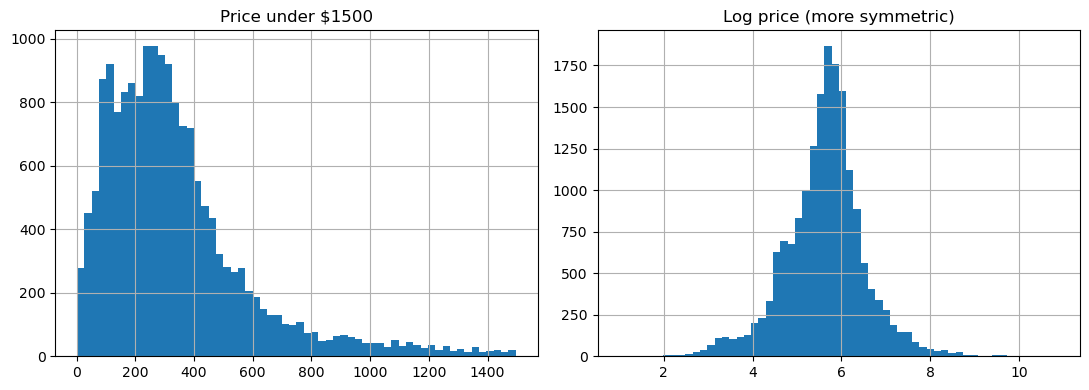

count    17786.0
mean       432.0
std        894.0
min          2.0
50%        291.0
95%       1147.0
99%       2889.0
max      52850.0


In [6]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (11, 4)

price_raw = pd.to_numeric(
    df['price'].astype(str).str.replace(r'[\$,]', '', regex=True), errors='coerce')

fig, ax = plt.subplots(1, 2)
price_raw[price_raw < 1500].hist(bins=60, ax=ax[0])
ax[0].set_title('Price under $1500')
np.log1p(price_raw).hist(bins=60, ax=ax[1])
ax[1].set_title('Log price (more symmetric)')
plt.tight_layout(); plt.show()

print(price_raw.describe([.5, .95, .99]).round(0).to_string())

**Decision:** the price distribution has a long right tail and some extreme values. We cap prices at the 99th percentile in Step 12.


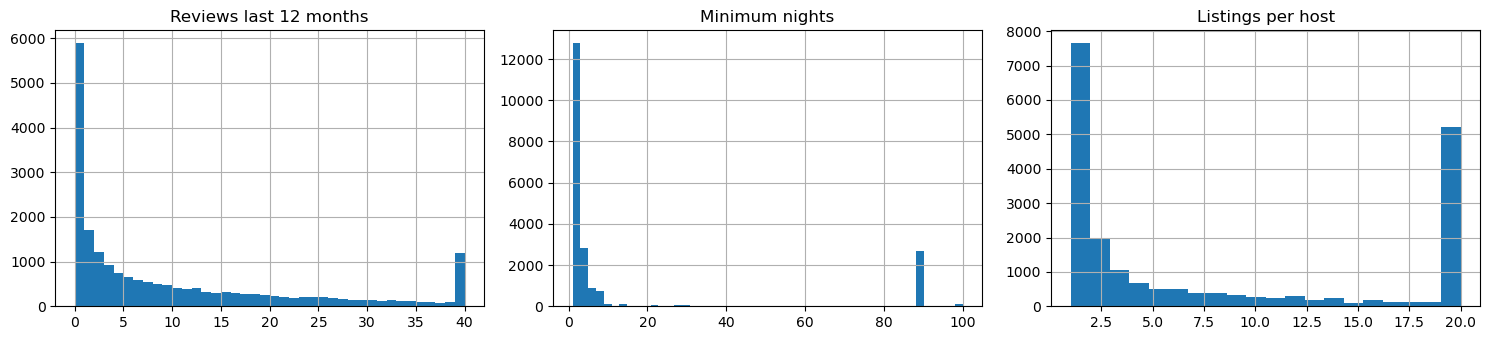

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
df['number_of_reviews_ltm'].clip(upper=40).hist(bins=40, ax=ax[0])
ax[0].set_title('Reviews last 12 months')
df['minimum_nights'].clip(upper=100).hist(bins=50, ax=ax[1])
ax[1].set_title('Minimum nights')
df['calculated_host_listings_count'].clip(upper=20).hist(bins=20, ax=ax[2])
ax[2].set_title('Listings per host')
plt.tight_layout(); plt.show()

**Decisions:**

- The number of listings with zero recent reviews supports using an activity filter.
- Minimum stays around 1 to 3 nights and 28 or 90 nights suggest different rental markets.
- The range of listings per host supports grouping hosts by size.


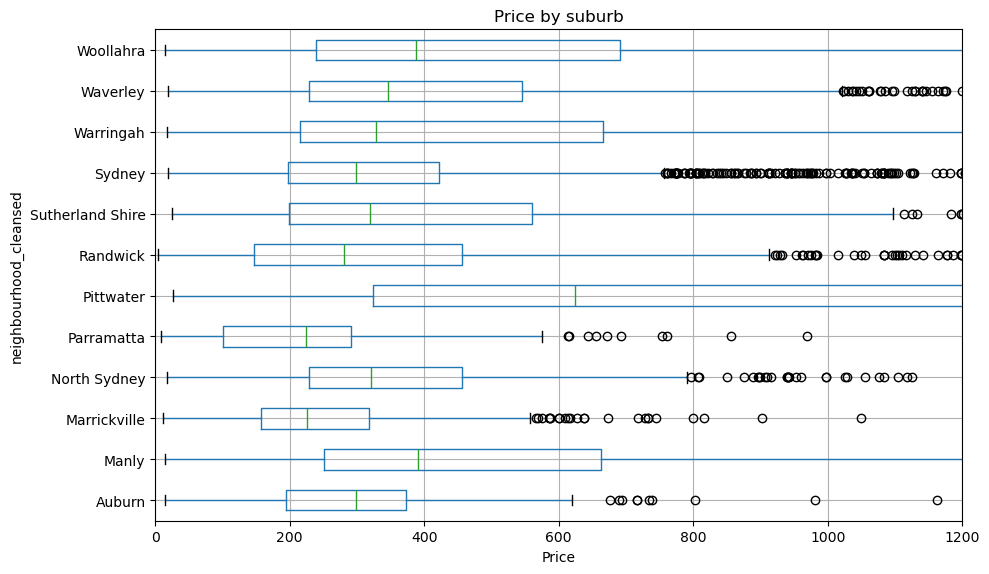

In [8]:
top = df['neighbourhood_cleansed'].value_counts().head(12).index
sub = df.assign(p=price_raw).query('neighbourhood_cleansed in @top')
sub.boxplot(column='p', by='neighbourhood_cleansed', vert=False, figsize=(10, 6))
plt.xlim(0, 1200); plt.suptitle(''); plt.title('Price by suburb'); plt.xlabel('Price')
plt.tight_layout(); plt.show()

**Decision:** prices vary by suburb, so we keep `neighbourhood_cleansed` as a model feature.


## Step 5: Remove unnecessary columns

Remove the columns confirmed to be completely empty in Step 2, along with URLs, scrape metadata, redundant fields and personal information that the analysis does not need.

We drop fields such as `host_name` and `host_about`. Results can be reported by suburb or host type without including individual names.


In [10]:
drop_cols = [
    # 13 columns confirmed to be entirely empty
    'neighbourhood', 'neighbourhood_group_cleansed', 'neighborhood_overview',
    'host_response_rate', 'host_acceptance_rate', 'host_response_time',
    'host_since', 'host_verifications', 'host_neighbourhood',
    'host_total_listings_count', 'host_thumbnail_url',
    'instant_bookable', 'calendar_updated',

    # URLs and scrape metadata with no pricing signal
    'listing_url', 'picture_url', 'host_url', 'host_profile_url',
    'host_picture_url', 'scrape_id', 'source', 'last_scraped',
    'calendar_last_scraped',

    # Redundant columns with better alternatives already kept
    'host_profile_id',              # host_id is the ID we use
    'host_listings_count',          # calculated_host_listings_count is more reliable
    'minimum_minimum_nights', 'maximum_minimum_nights',
    'minimum_maximum_nights', 'maximum_maximum_nights',
    'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm',

    # Quote details for a hypothetical 90-night stay
    'price_quote_checkin_date', 'price_quote_checkout_date',
    'price_quote_total_price', 'price_quote_price_per_night', 'price_quote_raw',

    # Personal information
    'host_name', 'host_about', 'host_location',
]

print(f'{"COLUMN":34s} {"FILLED":>7s}   SAMPLE')
print('-' * 90)
for c in drop_cols:
    if c in df.columns:
        filled = (1 - df[c].isnull().mean()) * 100
        sample = str(df[c].dropna().iloc[0])[:40] if df[c].notna().any() else '(empty)'
        print(f'{c:34s} {filled:6.1f}%   {sample}')

COLUMN                              FILLED   SAMPLE
------------------------------------------------------------------------------------------
neighbourhood                         0.0%   (empty)
neighbourhood_group_cleansed          0.0%   (empty)
neighborhood_overview                 0.0%   (empty)
host_response_rate                    0.0%   (empty)
host_acceptance_rate                  0.0%   (empty)
host_response_time                    0.0%   (empty)
host_since                            0.0%   (empty)
host_verifications                    0.0%   (empty)
host_neighbourhood                    0.0%   (empty)
host_total_listings_count             0.0%   (empty)
host_thumbnail_url                    0.0%   (empty)
instant_bookable                      0.0%   (empty)
calendar_updated                      0.0%   (empty)
listing_url                         100.0%   https://www.airbnb.com/rooms/11156
picture_url                         100.0%   https://a0.muscache.com/pictures/2797669
ho

In [11]:
before = df.shape[1]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

print(f'Columns: {before} -> {df.shape[1]}  (removed {before - df.shape[1]})')
print()
print('Kept:')
print(sorted(df.columns.tolist()))

Columns: 90 -> 52  (removed 38)

Kept:
['accommodates', 'amenities', 'availability_30', 'availability_365', 'availability_60', 'availability_90', 'availability_eoy', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'description', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'first_review', 'has_availability', 'host_has_profile_pic', 'host_id', 'host_identity_verified', 'host_is_superhost', 'hosts_time_as_host_months', 'hosts_time_as_host_years', 'hosts_time_as_user_months', 'hosts_time_as_user_years', 'id', 'last_review', 'latitude', 'license', 'longitude', 'maximum_nights', 'minimum_nights', 'name', 'neighbourhood_cleansed', 'number_of_reviews', 'number_of_reviews_l30d', 'number_of_reviews_ltm', 'number_of_reviews_ly', 'price', 'property_type', 'review_scores_accuracy', 'review_scores_checkin', 'rev

In [12]:
still_empty = df.isnull().mean()
still_empty = still_empty[still_empty == 1.0]
print('Empty columns remaining:', len(still_empty))
if len(still_empty): print(still_empty)

Empty columns remaining: 0


## Step 6: Convert price to a number

Prices arrive as text, such as `"$144.70"`. Remove the currency symbols and commas, then convert the values to numbers so we can analyse them.


In [13]:
df['price'] = pd.to_numeric(
    df['price'].astype(str).str.replace(r'[\$,]', '', regex=True), errors='coerce')

print(f'Missing price: {df["price"].isnull().mean()*100:.1f}%')
print(df['price'].describe([.5, .95, .99]).round(2).to_string())

Missing price: 13.5%
count    17786.00
mean       431.65
std        893.65
min          1.74
50%        291.00
95%       1147.46
99%       2888.80
max      52850.00


## Step 7: Fill missing bathroom values

About 27.8% of `bathrooms` values are missing. The `bathrooms_text` field often contains details such as "1 bath" or "2 shared baths", which we can use to fill the gaps. This brings missing values down to about 0.1%.

Using the text lets us keep rows that would otherwise be excluded. We also create a flag for shared bathrooms, which may help explain price differences.


In [14]:
bt = df['bathrooms_text'].astype(str).str.lower()

parsed = bt.str.extract(r'([\d\.]+)')[0].astype(float)
parsed = np.where(bt.str.contains('half'), 0.5, parsed)   # "half-bath" has no digit

df['bathrooms'] = df['bathrooms'].fillna(pd.Series(parsed, index=df.index))
df['is_shared_bath'] = bt.str.contains('shared').astype(int)

print(f'Bathrooms missing after repair: {df["bathrooms"].isnull().mean()*100:.2f}%')
print(df[['bathrooms_text', 'bathrooms', 'is_shared_bath']].head(6).to_string())

Bathrooms missing after repair: 0.12%
   bathrooms_text  bathrooms  is_shared_bath
0   1 shared bath        1.0               1
1  1 private bath        1.0               0
2          1 bath        1.0               0
3          1 bath        1.0               0
4          1 bath        1.0               0
5          1 bath        1.0               0


## Step 8: Fill missing bedroom values

Bedroom values are missing for about 52% of private rooms and 5% of entire homes. We use different rules to reflect these room types.

- For private and shared rooms, fill missing values with one bedroom.
- For other room types, use the median bedroom count for listings that accommodate the same number of guests.

Any remaining gaps are filled with one bedroom. We also flag the values that were missing so they can be reviewed later.


In [15]:
df['bedrooms_was_missing'] = df['bedrooms'].isnull().astype(int)

med_by_acc = df.groupby('accommodates')['bedrooms'].median()

df['bedrooms'] = np.where(
    df['bedrooms'].isna() & df['room_type'].isin(['Private room', 'Shared room']),
    1.0,
    df['bedrooms'].fillna(df['accommodates'].map(med_by_acc))
)
df['bedrooms'] = df['bedrooms'].fillna(1.0)   # catch any stragglers

print(f'Bedrooms missing: {pd.isnull(df["bedrooms"]).mean()*100:.2f}%')
print(f'Imputed rows: {df["bedrooms_was_missing"].sum():,}')

Bedrooms missing: 0.00%
Imputed rows: 3,107


## Step 9: Extract amenity features

The `amenities` column stores a JSON list in each cell. We turn it into an amenity count and flags for a pool, parking, air conditioning, Wi-Fi and a kitchen.


In [16]:
def parse_amenities(x):
    try:
        return json.loads(x)
    except Exception:
        return []

am = df['amenities'].fillna('[]').apply(parse_amenities)
df['amenity_count'] = am.apply(len)

for flag, kw in {'has_pool': 'pool', 'has_parking': 'parking',
                 'has_aircon': 'air conditioning', 'has_wifi': 'wifi',
                 'has_kitchen': 'kitchen'}.items():
    df[flag] = am.apply(lambda lst: int(any(kw in a.lower() for a in lst)))

print(f'Mean amenities per listing: {df["amenity_count"].mean():.1f}')
print(df[['amenity_count', 'has_pool', 'has_parking', 'has_aircon']].mean().round(2).to_string())

Mean amenities per listing: 37.3
amenity_count    37.30
has_pool          0.19
has_parking       0.75
has_aircon        0.63


## Step 10: Create listing and host features

Create a few features to make it easier to compare groups of listings.

- `is_active`: whether the listing has a review in the last year.
- `stay_type`: whether the minimum stay is under 28 nights or at least 28 nights.
- `host_type`: whether the host has one, two to four, or at least five listings.

We also convert superhost status into a numeric flag.


In [17]:
df['is_active'] = (df['number_of_reviews_ltm'] > 0).astype(int)

df['stay_type'] = np.where(df['minimum_nights'] >= 28, 'Long-stay', 'Short-stay')

df['host_type'] = pd.cut(df['calculated_host_listings_count'],
                         bins=[0, 1, 4, np.inf],
                         labels=['Individual', 'Small', 'Commercial'])

df['is_superhost'] = (df['host_is_superhost'] == 't').astype(int)

print(df['host_type'].value_counts().to_string())
print()
print(df['stay_type'].value_counts().to_string())
print(f'\nSuperhost share: {df["is_superhost"].mean()*100:.1f}%')

host_type
Commercial    9230
Individual    7643
Small         3700

stay_type
Short-stay    17586
Long-stay      2987

Superhost share: 33.4%


## Step 11: Filter the listings

Apply four rules to focus the study on active short-stay rentals. The output shows how many rows are removed at each stage.

1. Keep listings with a review in the last 12 months, using recent reviews as an indicator of activity.
2. Keep listings with a minimum stay under 28 nights to focus on short stays.
3. Keep listings with a price so they can be included in pricing analysis.
4. Keep entire homes and private rooms. Hotel rooms (56) and shared rooms (42) have small samples for comparison.

The expected result is around **13,055 listings**, or 63% of the original dataset. Check the printed counts to confirm the result.


In [18]:
funnel = {'raw': len(df)}

d = df[df['is_active'] == 1].copy();                  funnel['active'] = len(d)
d = d[d['stay_type'] == 'Short-stay'];                funnel['short_stay'] = len(d)
d = d[d['price'].notna()];                            funnel['has_price'] = len(d)
d = d[d['room_type'].isin(['Entire home/apt', 'Private room'])]
funnel['final'] = len(d)

prev = funnel['raw']
for stage, n in funnel.items():
    removed = prev - n if stage != 'raw' else 0
    print(f'{stage:12s} {n:7,}   removed: {removed:,}')
    prev = n

print(f'\nRetention: {funnel["final"]/funnel["raw"]*100:.1f}%')

raw           20,573   removed: 0
active        14,689   removed: 5,884
short_stay    14,244   removed: 445
has_price     13,116   removed: 1,128
final         13,055   removed: 61

Retention: 63.5%


## Step 12: Cap extreme prices

The highest price is over $34,000 per night. Values this high may represent unusual listings or placeholder prices and could have a large effect on the model.

Cap prices at the 99th percentile while keeping the rows. Use `price_capped` for modelling and retain `price` to report the original distribution.


In [19]:
cap = d['price'].quantile(0.99)
d['price_capped'] = d['price'].clip(upper=cap)

print(f'Cap at 99th percentile: ${cap:,.0f}')
print(f'Listings affected: {(d["price"] > cap).sum():,}')
print(d[['price', 'price_capped']].describe([.5, .95, .99]).round(0).to_string())

Cap at 99th percentile: $1,963
Listings affected: 131
         price  price_capped
count  13055.0       13055.0
mean     398.0         384.0
std      499.0         313.0
min       41.0          41.0
50%      308.0         308.0
95%      982.0         982.0
99%     1963.0        1963.0
max    34316.0        1963.0


## Step 13: Select the final columns and check the results

Keep the columns needed for the analysis, then review the remaining missing values and typical prices by room type and suburb. Check any unexpected results before saving.


In [20]:
keep = [
    'id', 'name', 'neighbourhood_cleansed', 'latitude', 'longitude',
    'property_type', 'room_type', 'accommodates', 'bedrooms', 'beds',
    'bathrooms', 'is_shared_bath', 'amenity_count',
    'has_pool', 'has_parking', 'has_aircon', 'has_wifi', 'has_kitchen',
    'price', 'price_capped', 'minimum_nights', 'availability_365',
    'number_of_reviews', 'number_of_reviews_ltm',
    'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location',
    'review_scores_value', 'review_scores_communication',
    'is_superhost', 'host_id', 'host_type', 'calculated_host_listings_count',
    'estimated_occupancy_l365d', 'estimated_revenue_l365d',
    'first_review', 'last_review', 'bedrooms_was_missing', 'license','is_superhost', 'host_id', 'host_type', 'calculated_host_listings_count',
    'hosts_time_as_host_years',
]
clean = d[[c for c in keep if c in d.columns]].copy()

print(f'Final shape: {clean.shape}')
print()
print('Remaining nulls:')
nulls = clean.isnull().mean()
print(nulls[nulls > 0].round(3).to_string() if (nulls > 0).any() else '  none')

Final shape: (13055, 44)

Remaining nulls:
beds                           0.035
bathrooms                      0.001
minimum_nights                 0.001
review_scores_cleanliness      0.000
review_scores_location         0.000
review_scores_value            0.000
review_scores_communication    0.000
license                        0.000


In [21]:
# Sanity check - do these numbers look like real Sydney apartments?
print(clean.groupby('room_type')[['price', 'bedrooms', 'review_scores_rating']]
      .median().round(1).to_string())
print()
print(clean.groupby('neighbourhood_cleansed')['price']
      .agg(['count', 'median']).sort_values('count', ascending=False).head(10).to_string())

                 price  bedrooms  review_scores_rating
room_type                                             
Entire home/apt  346.0       2.0                   4.8
Private room     121.5       1.0                   4.7

                        count   median
neighbourhood_cleansed                
Sydney                   3388  316.110
Waverley                 1077  359.470
Randwick                  643  298.500
Manly                     562  399.550
North Sydney              541  332.000
Pittwater                 490  551.600
Auburn                    481  295.000
Warringah                 479  337.240
Sutherland Shire          366  329.330
Woollahra                 332  394.675


## Step 14: Save the cleaned data

Save the cleaned dataset to `listings_clean.csv` for the price model, the review sentiment join and Power BI.


In [22]:
clean.to_csv('listings_clean.csv', index=False)
print(f'Saved {len(clean):,} rows x {clean.shape[1]} columns')

Saved 13,055 rows x 44 columns


## Summary of the cleaning work

- Started with 20,573 listings and retained approximately 13,055 active short-stay rentals.
- Identified about 28.6% with no recent reviews, 14.5% requiring long stays and 45% managed by hosts with at least five listings.
- Reduced missing bathroom values from 27.8% to about 0.1% using the bathroom descriptions.
- Compared occupancy estimates with review activity to check for a possible dependency that could affect revenue modelling.
- Recorded how many listings were removed by each filtering rule.

**Next:** add sentiment scores from `reviews.csv`, then build the fair-value price model.
